# Problem statement : 
#### Imagine you are working for an e-commerce company , and the marketing team wants to target customer more effectively by creating segments based on their purchising bahaviour , however , traditional segmentation methods are not providing satisfactory results.

#### Solution : 
#### Use DBSCAN to identify clusters of customers with similar purching patterns.

In [1]:
# Step 1 : Import Required Libraries

# Import libraries for data handling 
import numpy as np 
import pandas as pd

# Import Libraries for visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Import Preprocessing and clustering tools 
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# Import dimensionality reductin tool 
from sklearn.decomposition import PCA

# Import nearest neighbor model for eps tuning
from sklearn.neighbors import NearestNeighbors

# Import clustering evalution metrics 
from sklearn.metrics import silhouette_score , davies_bouldin_score , calinski_harabasz_score

# Set default plot size 
plt.rcParams["figure.figsize"] = (10 , 6)

# Set plot style 
sns.set_style("whitegrid")

In [2]:
# Step 2 Load Dataset 

# Load the customer dataset 
df = pd.read_csv("ecommerce_customers.csv")

# Display first 5 rows
print("First 5 Rows :")
print(df.head())

# Display dataset shape 
print("\nDataset Shape : ",df.shape)

# Display column names 
print("\nColumn Names : ")
print(df.columns.tolist())

First 5 Rows :
  Customer_ID  Annual_Income  Spending_Score  Purchase_Frequency  \
0     CUST218          89709              23                  15   
1     CUST067          84424              72                  18   
2     CUST010          89340              86                  16   
3     CUST194          24484              14                   4   
4     CUST016          80502              70                  20   

   Average_Order_Value  
0               336.44  
1               264.72  
2               234.17  
3                49.56  
4               203.05  

Dataset Shape :  (230, 5)

Column Names : 
['Customer_ID', 'Annual_Income', 'Spending_Score', 'Purchase_Frequency', 'Average_Order_Value']


In [3]:
# Step 3 : Basic Data Understanding 

# Show dataset information 
print("\nDataset Info :")
print(df.info())

# Check missing values 
print("\nCheck Missing Values : ")
print(df.isnull().sum())

# Show statistical summary 
print("\nStatistical Summary : ")
print(df.describe())


Dataset Info :
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 230 entries, 0 to 229
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          230 non-null    object 
 1   Annual_Income        230 non-null    int64  
 2   Spending_Score       230 non-null    int64  
 3   Purchase_Frequency   230 non-null    int64  
 4   Average_Order_Value  230 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 9.1+ KB
None

Check Missing Values : 
Customer_ID            0
Annual_Income          0
Spending_Score         0
Purchase_Frequency     0
Average_Order_Value    0
dtype: int64

Statistical Summary : 
       Annual_Income  Spending_Score  Purchase_Frequency  Average_Order_Value
count     230.000000      230.000000          230.000000           230.000000
mean    61304.504348       55.295652           11.691304           150.213870
std     24268.710867       25.518201      

In [4]:
# Step 4 : Data cleaning 
# Remove extra spaces from column names 
df.columns = df.columns.str.strip()

# Drop duplicate rows if present 
df.drop_duplicates(inplace=True)

# Confirm missing values after cleaning 
print("\nMissing values after cleaning : ")
print(df.isnull().sum())


Missing values after cleaning : 
Customer_ID            0
Annual_Income          0
Spending_Score         0
Purchase_Frequency     0
Average_Order_Value    0
dtype: int64


In [5]:
# Step 5 Select Features for Clustering 

# Select important purchasing behaviour features 
features = [
    "Annual_Income",
    "Spending_Score",
    "Purchase_Frequency",
    "Average_Order_Value"
]

# Create feature matrix 
X = df[features]

# display selected features 
print("\nSelected Features : ")
print(X.head())


Selected Features : 
   Annual_Income  Spending_Score  Purchase_Frequency  Average_Order_Value
0          89709              23                  15               336.44
1          84424              72                  18               264.72
2          89340              86                  16               234.17
3          24484              14                   4                49.56
4          80502              70                  20               203.05


In [6]:
# Feature Scaling 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# show scaled data shape
print("\nScaled Data Shape : " , X_scaled.shape)

# Print training insight 
print("\nModel Training Insight : ")
print("DBSCAN is a density - based unsupervised clustering algorithm.")
print("Feature scaling is important because DBSCAN depends on distances between data points . ")
print("StandardScaler ensures that all features contribute equally during clustering . ")


Scaled Data Shape :  (230, 4)

Model Training Insight : 
DBSCAN is a density - based unsupervised clustering algorithm.
Feature scaling is important because DBSCAN depends on distances between data points . 
StandardScaler ensures that all features contribute equally during clustering . 


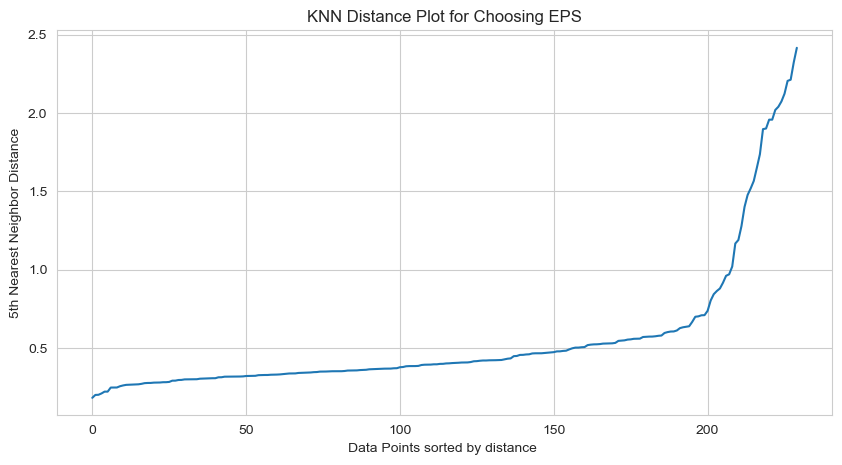


 Visualization Insight - KNN Distance Plot : 
The elbow point in this graph helps identify a suitable eps value for DBSCAN.
A clear bend in the curve suggests the natural density threshold for separating clusters from noise .


In [7]:
# step 7 : Find Good EPS value using K-Nearest Neighbors Distance Plot

# Fit nearest neighbors model
neighbors = NearestNeighbors(n_neighbors= 5)
neighbors_fit = neighbors.fit(X_scaled)

# Compute distances to nearest neighbors 
distances , indices = neighbors_fit.kneighbors(X_scaled)

# Sort the 5th nearest neighbor distances 
distances = np.sort(distances[: , 4])

# Plot KNN distance graph
plt.figure(figsize=(10,5))
plt.plot(distances)
plt.title("KNN Distance Plot for Choosing EPS")
plt.xlabel("Data Points sorted by distance ")
plt.ylabel("5th Nearest Neighbor Distance")
plt.savefig("images/KNN Distance plot for choosing EPS.png")
plt.show()

# Print Visualization insight 
print("\n Visualization Insight - KNN Distance Plot : ")
print("The elbow point in this graph helps identify a suitable eps value for DBSCAN.")
print("A clear bend in the curve suggests the natural density threshold for separating clusters from noise .")


In [8]:
# Step 8 : Apply DBSCAN

# Initialize DBSCAN model 
dbscan = DBSCAN(eps=0.9 , min_samples=5)

# Fit the model and get cluster labels 
clusters = dbscan.fit_predict(X_scaled)

# Add cluster labels to dataset 
df["Cluster"] = clusters

# Show cluster labels count 
print("\nCluster Labels : ")
print(df["Cluster"].value_counts().sort_index())

# Print model insight
print("\nModel Training Insight:")
print("DBSCAN groups customers based on density instead of predefined cluster count.")
print("It can discover natural clusters and also detect outliers as noise points.")
print("Unlike K-Means, DBSCAN does not require the number of clusters in advance.")



Cluster Labels : 
Cluster
-1     20
 0    210
Name: count, dtype: int64

Model Training Insight:
DBSCAN groups customers based on density instead of predefined cluster count.
It can discover natural clusters and also detect outliers as noise points.
Unlike K-Means, DBSCAN does not require the number of clusters in advance.


In [9]:
# Step 9 : Check Number of Clusters and Noise Points

# Calculate number of clusters exclusing noise 
n_clusters = len(set(clusters)) - (1 if -1 in clusters else 0)

# Count noise points 
n_noise = list(clusters).count(-1)

# Print Cluster Summary 
print("\nNumber of Clusters Found : " , n_clusters)
print("Number of Noise Points : " , n_noise)

# Print prediction insight
print("\nModel Prediction Insight:")
print("Each customer is assigned a cluster label.")
print("Labels 0, 1, 2, ... represent customer segments.")
print("Label -1 represents noise or unusual customers with different purchasing behavior.")



Number of Clusters Found :  1
Number of Noise Points :  20

Model Prediction Insight:
Each customer is assigned a cluster label.
Labels 0, 1, 2, ... represent customer segments.
Label -1 represents noise or unusual customers with different purchasing behavior.


C:\Users\sagar\AppData\Local\Temp\ipykernel_25736\1227331082.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x = "Cluster" , data = df , palette="Set2")


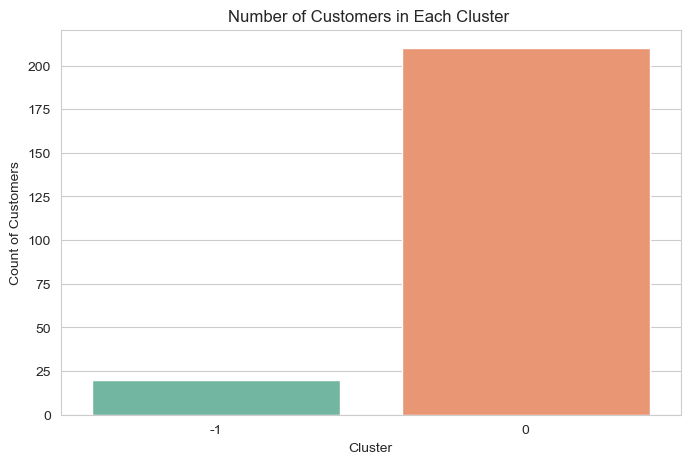


Visualization Insight - Cluster Count Plot:
This chart shows how customers are distributed across different clusters.
A large cluster indicates a dominant customer segment.
If cluster -1 is present, it confirms that DBSCAN detected outliers.


In [10]:
# Step 10 : Visualize Cluster Count 

# Plot customer count per cluster 
plt.figure(figsize=(8,5))
sns.countplot(x = "Cluster" , data = df , palette="Set2")
plt.title("Number of Customers in Each Cluster ")
plt.xlabel("Cluster")
plt.ylabel("Count of Customers")
plt.savefig("images/Number of Customers in Each Cluster.png")
plt.show()

# Print visualization insight
print("\nVisualization Insight - Cluster Count Plot:")
print("This chart shows how customers are distributed across different clusters.")
print("A large cluster indicates a dominant customer segment.")
print("If cluster -1 is present, it confirms that DBSCAN detected outliers.")


Visualization Insight - PCA Plot:
PCA reduces multiple features into two dimensions for easier visualization.
If clusters appear clearly separated, it indicates effective segmentation.
Points far away from major groups usually represent noise or outliers.


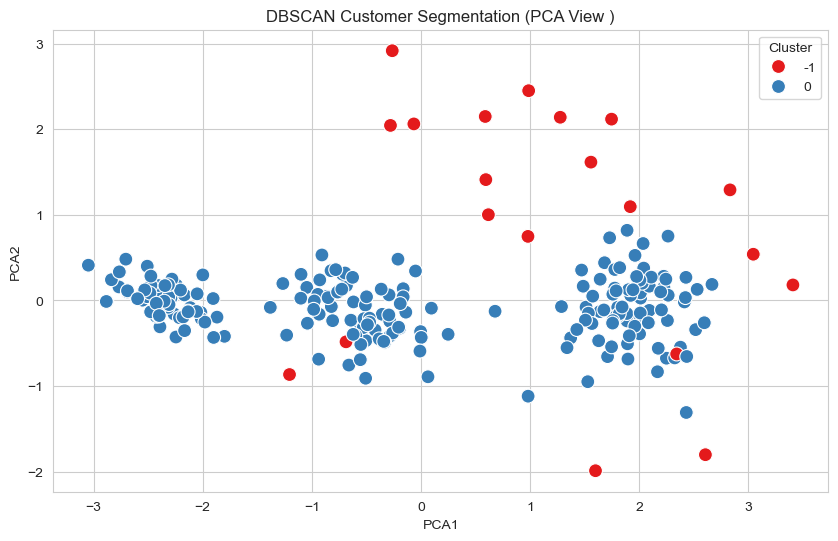

In [11]:
# Step 11 : pCA for 2D Visualization

# Reduce  dimensions to 2 components 
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Add PCA coolumns to dataset 
df["PCA1"] = X_pca[: , 0]
df["PCA2"] = X_pca[: , 1]

# Plot clusters in 2d PCA space 
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=df,
    x = "PCA1",
    y = "PCA2",
    hue="Cluster",
    palette="Set1",
    s = 100
)
plt.title("DBSCAN Customer Segmentation (PCA View )")
plt.savefig("images/DBSCAN Customer Segmentation (PCA View).png")

# Print visualization insight
print("\nVisualization Insight - PCA Plot:")
print("PCA reduces multiple features into two dimensions for easier visualization.")
print("If clusters appear clearly separated, it indicates effective segmentation.")
print("Points far away from major groups usually represent noise or outliers.")


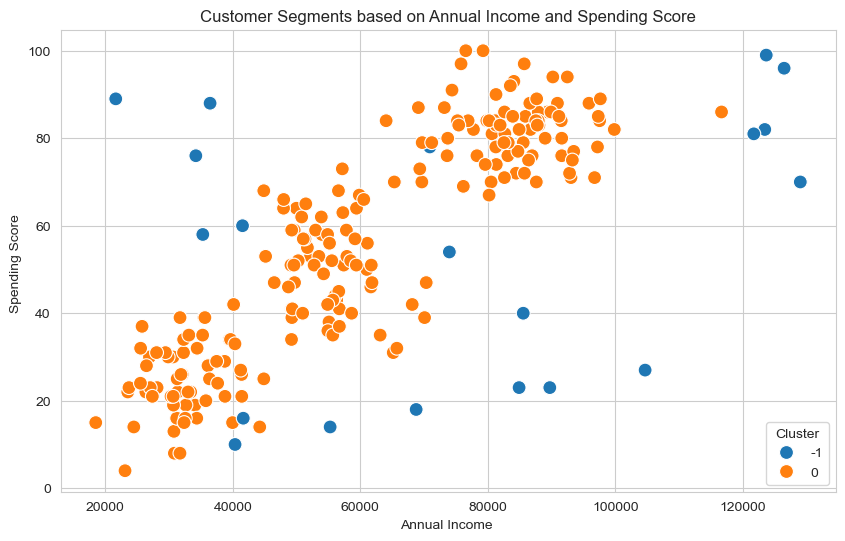


Visualization Insight - Income vs Spending Score:
Customers with high income and high spending score represent premium-value shoppers.
Customers with low income and low spending score may be budget-sensitive buyers.
This view helps the marketing team design segment-specific targeting strategies.


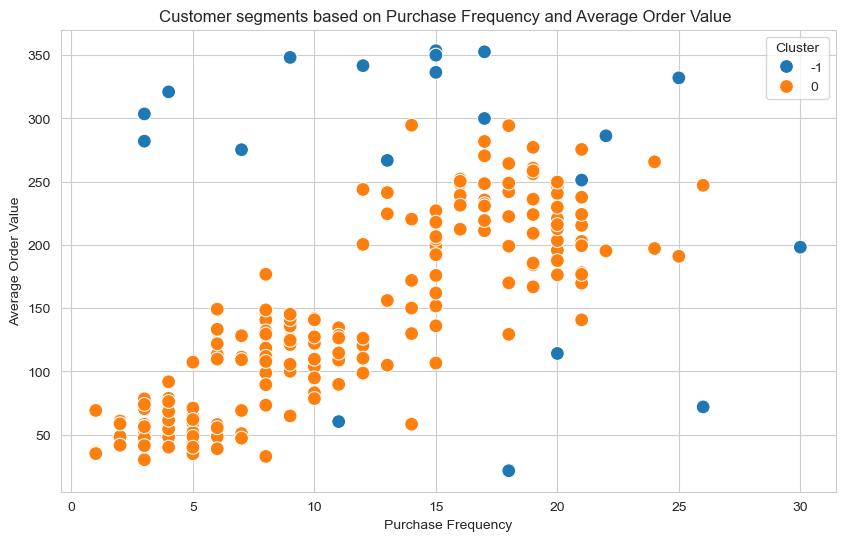


Visualization Insight - Frequency vs Order Value:
Customers with high purchase frequency and high average order value are loyal and profitable.
Customers with low frequency and low order value may need retention campaigns.
This plot highlights behavior-based customer value differences.


In [12]:
# Step 12 : Visulization using Important Business Features 

# Plot : 1  Annual Income Vs spending Score 
plt.figure(figsize=(10,6))
sns.scatterplot(
    data = df,
    x = "Annual_Income",
    y = "Spending_Score",
    hue = "Cluster",
    palette= "tab10",
    s = 100
    
)
plt.title("Customer Segments based on Annual Income and Spending Score")
plt.xlabel("Annual Income ")
plt.ylabel("Spending Score ")
plt.savefig("images/Customer Segments based on Annual Income and Spending Score.jpeg")
plt.show()

# Print insight for first business plot
print("\nVisualization Insight - Income vs Spending Score:")
print("Customers with high income and high spending score represent premium-value shoppers.")
print("Customers with low income and low spending score may be budget-sensitive buyers.")
print("This view helps the marketing team design segment-specific targeting strategies.")

# Plot 2 Purchase Frequency Vs Average Order Value
plt.figure(figsize=(10,6))
sns.scatterplot(
    data = df,
    x = "Purchase_Frequency",
    y = "Average_Order_Value",
    hue = "Cluster",
    palette = "tab10",
    s = 100
)
plt.title("Customer segments based on Purchase Frequency and Average Order Value ")
plt.xlabel("Purchase Frequency")
plt.ylabel("Average Order Value")
plt.savefig("images/Purchase Frequency Vs Average Order Value.png")
plt.show()

# Print insight for second business plot
print("\nVisualization Insight - Frequency vs Order Value:")
print("Customers with high purchase frequency and high average order value are loyal and profitable.")
print("Customers with low frequency and low order value may need retention campaigns.")
print("This plot highlights behavior-based customer value differences.")


Visualization Insight - Pairplot:
The pairplot shows relationships between all selected features.
It helps verify whether clusters are naturally separated across different feature combinations.
This gives a complete visual understanding of customer segmentation patterns.


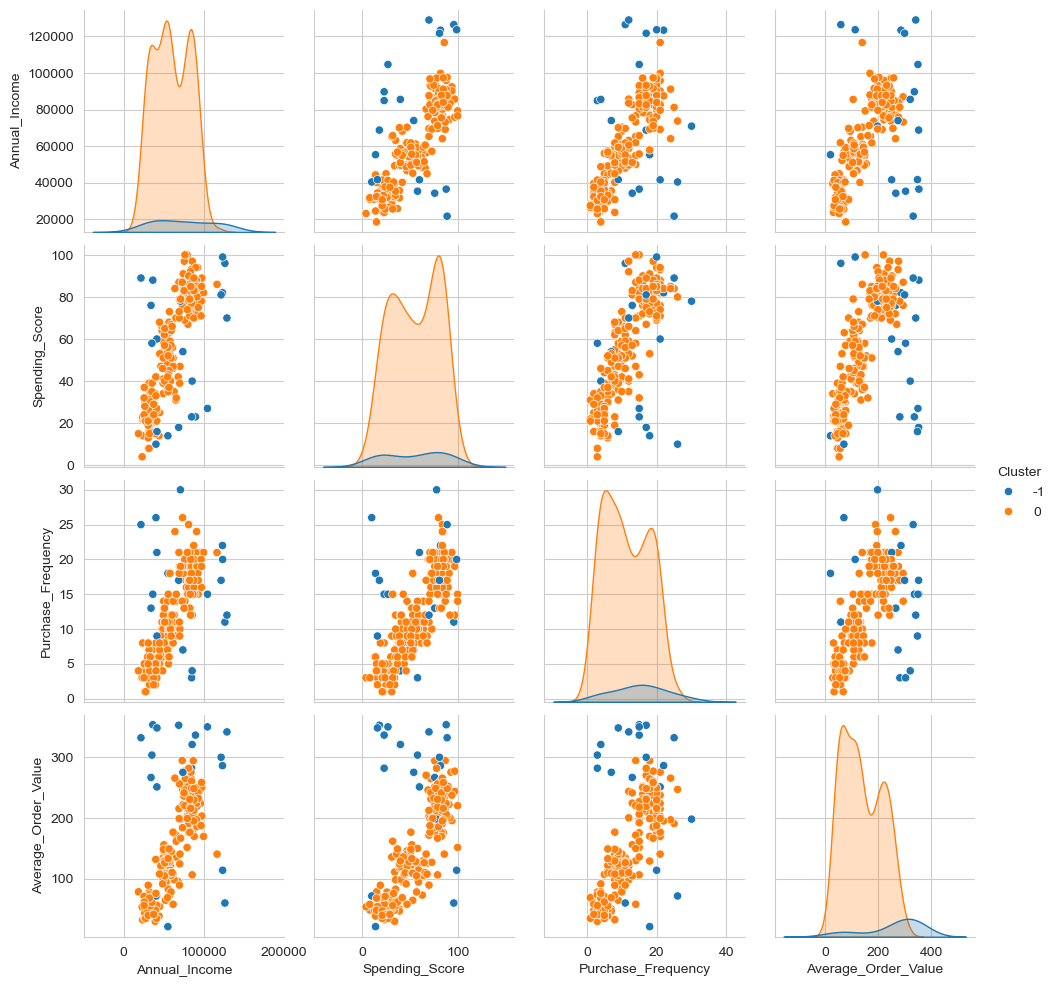

In [13]:
# Step 13 : Pairplot for All Features 

# Create pariplot for all features 
sns.pairplot(df , vars=features , hue="Cluster" , palette= "tab10")
plt.savefig("images/Pairplot.png")

# Print visualization insight
print("\nVisualization Insight - Pairplot:")
print("The pairplot shows relationships between all selected features.")
print("It helps verify whether clusters are naturally separated across different feature combinations.")
print("This gives a complete visual understanding of customer segmentation patterns.")


In [14]:
# Step 14 : Cluster - wise Summary

# Compute mean values for each cluster 
cluster_summay = df.groupby("Cluster")[features].mean().round(2)

# Display cluster summary
print("\nCluster-wise Mean Summary:")
print(cluster_summay)

# Print insight
print("\nCluster Summary Insight:")
print("This table explains the average behavior of each customer segment.")
print("It helps identify premium, regular, low-engagement, and unusual customer groups.")
print("These averages are useful for translating model output into business decisions.")


Cluster-wise Mean Summary:
         Annual_Income  Spending_Score  Purchase_Frequency  \
Cluster                                                      
-1            75448.55           55.10               15.15   
 0            59957.45           55.31               11.36   

         Average_Order_Value  
Cluster                       
-1                    258.33  
 0                    139.92  

Cluster Summary Insight:
This table explains the average behavior of each customer segment.
It helps identify premium, regular, low-engagement, and unusual customer groups.
These averages are useful for translating model output into business decisions.


In [15]:
# Step 15 : Customer Count per Cluster 

# Count customers in each cluster 
cluster_count = df["Cluster"].value_counts().sort_index().reset_index()
cluster_count.columns = ["Cluster" , "Customer_Count"]

# Display customer count 
print("\nCluster-wise Customer Count : ")
print(cluster_count)

# Print insight
print("\nCustomer Count Insight:")
print("This table shows the size of each customer segment.")
print("Large clusters can be targeted with broad campaigns.")
print("Small clusters may require specialized or niche marketing strategies.")


Cluster-wise Customer Count : 
   Cluster  Customer_Count
0       -1              20
1        0             210

Customer Count Insight:
This table shows the size of each customer segment.
Large clusters can be targeted with broad campaigns.
Small clusters may require specialized or niche marketing strategies.


In [16]:
# Step 16 : Clustering Evaluation

# Exclude noise points for evaluation 
mask = df["Cluster"] != -1
X_eval = X_scaled[mask]
labels_eval = df.loc[mask , "Cluster"]

# Print evaluation metrics 
print("\nClustering Evaluation Metrics : ")

if len(set(labels_eval)) > 1 :
    sil_score = silhouette_score(X_eval , labels_eval)
    df_score = davies_bouldin_score(X_eval , labels_eval)
    ch_score = calinski_harabasz_score(X_eval , labels_eval)
    
    print("silhouette_score : " , round(sil_score , 3))
    print("davies_bouldin_score : " , round(df_score , 3))
    print("calinski_harabasz_score : " , round(ch_score , 3))
    
    print ("\nEvaluation Insight:")
    print("A higher Silhouette Score indicates better cluster separation.")
    print("A lower Davies-Bouldin Score indicates compact and well-separated clusters.")
    print("A higher Calinski-Harabasz Score suggests stronger clustering structure.")
else:
    print("Evaluation metrics cannot be computed properly because enough meaningful clusters were not formed.")


Clustering Evaluation Metrics : 
Evaluation metrics cannot be computed properly because enough meaningful clusters were not formed.


In [17]:
# Step 17 : Business Insights and Business Impact 
# Print business insights for each cluster
print("\nBusiness Insights / Business Impact:")

for cluster_id in sorted(df["Cluster"].unique()):
    temp = df[df["Cluster"] == cluster_id]

    avg_income = round(temp["Annual_Income"].mean(), 2)
    avg_spending = round(temp["Spending_Score"].mean(), 2)
    avg_frequency = round(temp["Purchase_Frequency"].mean(), 2)
    avg_order = round(temp["Average_Order_Value"].mean(), 2)
    count = len(temp)

    print(f"\nCluster {cluster_id} | Customers: {count}")
    print(f"Average Income            : {avg_income}")
    print(f"Average Spending Score    : {avg_spending}")
    print(f"Average Purchase Frequency: {avg_frequency}")
    print(f"Average Order Value       : {avg_order}")

    if cluster_id == -1:
        print("Insight: These are noise or outlier customers with unusual purchasing behavior.")
        print("Business Impact: The company can monitor them for niche demand, anomaly behavior, or fraud risk.")

    elif avg_income >= 70000 and avg_spending >= 70:
        print("Insight: This segment contains premium high-value customers.")
        print("Business Impact: Target them with exclusive offers, premium memberships, and personalized recommendations.")

    elif avg_frequency >= 10 and avg_order >= 100:
        print("Insight: This segment includes regular and highly engaged customers.")
        print("Business Impact: Loyalty programs, retention offers, and cross-selling can increase revenue from this group.")

    elif avg_spending < 40:
        print("Insight: This segment represents low-engagement or price-sensitive customers.")
        print("Business Impact: Discount campaigns, festive offers, and reactivation strategies may improve conversion.")

    else:
        print("Insight: This segment shows moderate purchasing behavior.")
        print("Business Impact: Targeted product suggestions and personalized campaigns can improve their order value.")



Business Insights / Business Impact:

Cluster -1 | Customers: 20
Average Income            : 75448.55
Average Spending Score    : 55.1
Average Purchase Frequency: 15.15
Average Order Value       : 258.34
Insight: These are noise or outlier customers with unusual purchasing behavior.
Business Impact: The company can monitor them for niche demand, anomaly behavior, or fraud risk.

Cluster 0 | Customers: 210
Average Income            : 59957.45
Average Spending Score    : 55.31
Average Purchase Frequency: 11.36
Average Order Value       : 139.92
Insight: This segment includes regular and highly engaged customers.
Business Impact: Loyalty programs, retention offers, and cross-selling can increase revenue from this group.


In [18]:
# Step 18 : Final Conclusion 
print("\nFinal Conclusion:")
print("DBSCAN successfully segmented customers based on purchasing behavior and identified outliers.")
print("The model created meaningful customer groups without requiring a predefined number of clusters.")
print("These insights can help the marketing team improve targeting, retention, and personalized campaign strategies.")


Final Conclusion:
DBSCAN successfully segmented customers based on purchasing behavior and identified outliers.
The model created meaningful customer groups without requiring a predefined number of clusters.
These insights can help the marketing team improve targeting, retention, and personalized campaign strategies.
